# 03 - Split & Preprocessing

Prepare `ai-real-images` for training. This notebook produces the **shared foundation** every training pipeline (04–09) consumes:

1. A **stratified validation split** carved from the train set (it ships only train/test).
2. A one-time **256×256 disk cache** (uint8 memmap per split) so epochs don't re-decode ~48 GB of JPEGs — this also **resizes everything to a fixed square**, neutralizing the real-vs-fake *resolution shortcut* found in EDA.
3. **Training-set normalization stats** (for the from-scratch CNNs; pretrained backbones use ImageNet stats).
4. The canonical **Dataset / DataLoaders** (`utils.datasets`), sanity-checked.

Heavy logic lives in `utils/datasets.py`; the loops/asserts/plots stay visible here.

**Sections:** 0 Setup · 1 Load cleaned manifest · 2 Validation split · 3 Build 256² cache · 4 Normalization stats · 5 Dataset & loaders · 6 Visualize a batch · 7 Summary.

Outputs (all under gitignored `data/ai-real-images/`): `manifest_split.csv`, `cache/cache_{train,val,test}_256.npy` (~11 GB), `norm_stats.json`.

## 0 - Setup

In [1]:
import sys
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D
from utils.paths import repo_paths

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
AIR_DIR = DATA_DIR / "ai-real-images"
CACHE_DIR = AIR_DIR / "cache"
SEED = 42
VAL_FRACTION = 0.10
print("ai-real-images dir:", AIR_DIR)

ai-real-images dir: C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\notebooks\data\ai-real-images


## 1 - Load the cleaned manifest

Read `manifest_clean.csv`, keep only `keep==True` rows (drops corrupt + de-duplicated/leakage rows from notebook 02). It has `train`/`test` splits only — no validation yet. EDA showed real photos are systematically larger than fakes (a resolution shortcut); §3 resizes everything to a fixed 256² square to remove it.

In [2]:
clean = pd.read_csv(AIR_DIR / "manifest_clean.csv")
df = clean[clean["keep"]].copy()
print("kept rows:", len(df))
print(df.groupby(["split", "label"]).size())

kept rows: 59882
split  label
test   fake      5977
       real      5986
train  fake     23938
       real     23981
dtype: int64


## 2 - Carve a stratified validation split

Take 10% of the **train** rows as validation, stratified by `label` (seeded). The `test` split is untouched. We write the canonical 3-way assignment into a new column `split_final` (the original `split` is kept for provenance).

In [3]:
train_rows = df[df["split"] == "train"]
tr_idx, va_idx = train_test_split(
    train_rows.index, test_size=VAL_FRACTION, stratify=train_rows["label"], random_state=SEED,
)
df["split_final"] = df["split"]            # test stays test
df.loc[va_idx, "split_final"] = "val"

print(df.groupby(["split_final", "label"]).size())
# Sanity: test set must be unchanged.
assert set(df.loc[df.split_final == 'test', 'filepath']) == set(clean.loc[(clean.keep) & (clean.split == 'test'), 'filepath'])
print("\ntest set unchanged \u2713")

split_final  label
test         fake      5977
             real      5986
train        fake     21544
             real     21583
val          fake      2394
             real      2398
dtype: int64

test set unchanged ✓


## 3 - Build the 256² disk cache (one-time)

For each split we assign a `cache_idx` (row position) and write a uint8 memmap `cache_<split>_256.npy` via `D.build_cache` (Resize-shorter-side→256 + CenterCrop). This is **idempotent** — already-built caches are skipped. The combined assignment (`split_final` + `cache_idx`) is saved to `manifest_split.csv`.

*First run decodes all ~60k images (a few–several minutes) and writes ~11 GB. Subsequent runs are instant.*

In [4]:
CACHE_DIR.mkdir(parents=True, exist_ok=True)
parts = []
for split in ["train", "val", "test"]:
    sub = df[df["split_final"] == split].reset_index(drop=True)
    sub["cache_idx"] = np.arange(len(sub), dtype=np.int64)
    n = D.build_cache(sub, CACHE_DIR / f"cache_{split}_{D.CACHE_SIZE}.npy")
    print(f"{split:5s} cached {n:,}")
    parts.append(sub)

manifest_split = pd.concat(parts, ignore_index=True)
split_path = AIR_DIR / "manifest_split.csv"
manifest_split.to_csv(split_path, index=False)
print("saved", split_path)
for split in ["train", "val", "test"]:
    mm = np.load(CACHE_DIR / f"cache_{split}_{D.CACHE_SIZE}.npy", mmap_mode="r")
    print(f"  cache_{split}: shape {mm.shape} dtype {mm.dtype}")
    del mm

cache_train_256.npy:   0%|          | 0/43127 [00:00<?, ?it/s]

C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (98058240 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (99991727 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (98806617 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:3574: 

train cached 43,127


cache_val_256.npy:   0%|          | 0/4792 [00:00<?, ?it/s]

C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


val   cached 4,792


cache_test_256.npy:   0%|          | 0/11963 [00:00<?, ?it/s]

C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (143040000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (121554000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


test  cached 11,963
saved C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\notebooks\data\ai-real-images\manifest_split.csv
  cache_train: shape (43127, 256, 256, 3) dtype uint8
  cache_val: shape (4792, 256, 256, 3) dtype uint8
  cache_test: shape (11963, 256, 256, 3) dtype uint8


## 4 - Training normalization stats

Compute per-channel mean/std on the **train** cache only (no leakage) for the from-scratch CNNs (128px). Pretrained backbones (`cnn-finetune`, `vit-lora`, `clip-probe`) instead use **ImageNet** stats. Save the dataset stats to `norm_stats.json`.

In [5]:
train_mm = np.load(CACHE_DIR / f"cache_train_{D.CACHE_SIZE}.npy", mmap_mode="r")
mean, std = D.compute_norm_stats(train_mm)
del train_mm
(AIR_DIR / "norm_stats.json").write_text(json.dumps(
    {"mean": mean, "std": std, "size": D.CACHE_SIZE, "split": "train", "n": int(len(manifest_split[manifest_split.split_final == 'train']))}, indent=2))
print("dataset (train) stats  mean:", [round(x, 4) for x in mean], " std:", [round(x, 4) for x in std])
print("imagenet stats         mean:", D.IMAGENET_MEAN, " std:", D.IMAGENET_STD)

dataset (train) stats  mean: [0.458, 0.4296, 0.3962]  std: [0.3033, 0.2861, 0.289]
imagenet stats         mean: (0.485, 0.456, 0.406)  std: (0.229, 0.224, 0.225)


## 5 - Define & sanity-check the Dataset and loaders

Build loaders at both working sizes: **128px / dataset-norm** (from-scratch CNNs) and **224px / ImageNet-norm** (backbones). Verify batch shapes, label dtype/balance, and that the `Dataset` **pickles** (required for Windows DataLoader workers). We use `num_workers=0` here for a quick check; training notebooks raise it.

In [6]:
loaders_128 = D.make_loaders(split_path, working_size=128, batch_size=64, num_workers=0, norm="dataset")
loaders_224 = D.make_loaders(split_path, working_size=224, batch_size=32, num_workers=0, norm="imagenet")

for name, loaders in [("128/dataset", loaders_128), ("224/imagenet", loaders_224)]:
    xb, yb = next(iter(loaders["train"]))
    print(f"[{name}] train batch x={tuple(xb.shape)} {xb.dtype}  y={tuple(yb.shape)} {yb.dtype}  fake-frac={yb.float().mean():.2f}")
    print(f"           sizes: train={len(loaders['train'].dataset):,} val={len(loaders['val'].dataset):,} test={len(loaders['test'].dataset):,}")

pickle.loads(pickle.dumps(loaders_128["train"].dataset))
print("Dataset pickles \u2713 (spawn-safe for num_workers>0)")

C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\notebooks\utils\datasets.py:166: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  t = torch.from_numpy(arr).permute(2, 0, 1).contiguous()    # CHW uint8


[128/dataset] train batch x=(64, 3, 128, 128) torch.float32  y=(64,) torch.float32  fake-frac=0.52
           sizes: train=43,127 val=4,792 test=11,963
[224/imagenet] train batch x=(32, 3, 224, 224) torch.float32  y=(32,) torch.float32  fake-frac=0.47
           sizes: train=43,127 val=4,792 test=11,963
Dataset pickles ✓ (spawn-safe for num_workers>0)


## 6 - Visualize a batch

Un-normalize and show a few train images (with light aug) and eval images. Confirm real and fake now share the same square size (shortcut removed) and that the eval transform is deterministic.

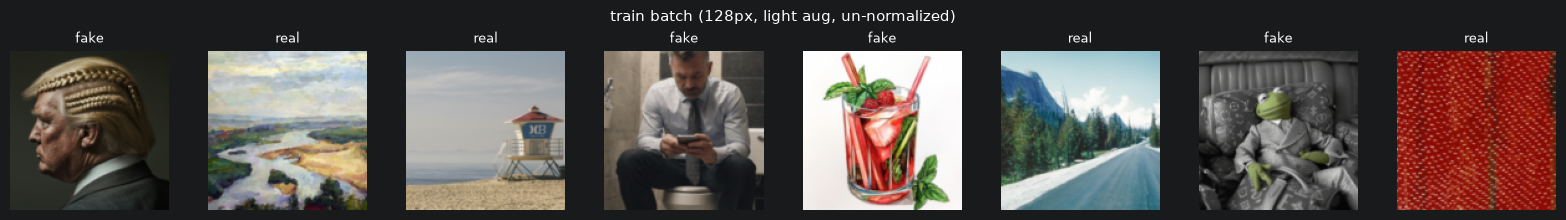

In [7]:
mean128, std128 = D.resolve_stats("dataset", AIR_DIR)
xb, yb = next(iter(loaders_128["train"]))
imgs = D.denormalize(xb[:8], mean128, std128).permute(0, 2, 3, 1).numpy()
fig, axes = plt.subplots(1, 8, figsize=(16, 2.2))
for ax, img, y in zip(axes, imgs, yb[:8]):
    ax.imshow(img); ax.axis("off"); ax.set_title("fake" if y > 0.5 else "real", fontsize=9)
fig.suptitle("train batch (128px, light aug, un-normalized)", fontsize=11)
plt.tight_layout(); plt.show()

## 7 - Summary / handoff

Produced under `data/ai-real-images/`: **`manifest_split.csv`** (adds `split_final` + `cache_idx`), **`cache/cache_{train,val,test}_256.npy`**, **`norm_stats.json`**.

Training notebooks load data with:
```python
from utils import datasets as D
loaders = D.make_loaders(split_path, working_size=128, batch_size=256, num_workers=8, norm="dataset")   # cnn-scratch / cnn-residual
loaders = D.make_loaders(split_path, working_size=224, batch_size=96,  num_workers=8, norm="imagenet")  # cnn-finetune
```
and the cross-generator OOD loader via `D.make_ood_loader(tiny_manifest, size, bs, mean, std)`.

**Next:** `04_cnn-scratch.ipynb`.